In [41]:
from sklearn.datasets import load_wine
import torch
wine = load_wine(as_frame=True)
X = wine.data
# are we missing a step here?
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)


In [42]:
X.shape

(178, 13)

In [43]:
X

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [44]:


class wine_auto_encoder(torch.nn.Module):
    def __init__(self, input_dim, latent_dim=3):
        super().__init__()
        self.fc1 = torch.nn.Linear(input_dim, 8)
        self.fc2 = torch.nn.Linear(8, latent_dim)
        self.fc3 = torch.nn.Linear(latent_dim, 8)
        self.fc4 = torch.nn.Linear(8, input_dim)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        x = self.encode(x)
        x = self.decode(x)
        return x

    def encode(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        return x

    def decode(self, x):
        x = self.fc3(x)
        x = self.relu(x)
        x = self.fc4(x)
        return x

model = wine_auto_encoder(input_dim=X.shape[1], latent_dim=2)
# reconstruction loss
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)
losses = []
for epoch in range(2501):
    optimizer.zero_grad()
    
    X_reconstructed = model(X_tensor)
    loss = criterion(X_reconstructed, X_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')

   

Epoch 0, Loss: 1.0586830377578735
Epoch 100, Loss: 0.49579575657844543
Epoch 200, Loss: 0.41437259316444397
Epoch 300, Loss: 0.38116782903671265
Epoch 400, Loss: 0.36046111583709717
Epoch 500, Loss: 0.3501640856266022
Epoch 600, Loss: 0.3446715772151947
Epoch 700, Loss: 0.34130004048347473
Epoch 800, Loss: 0.33882957696914673
Epoch 900, Loss: 0.33718499541282654
Epoch 1000, Loss: 0.33599692583084106
Epoch 1100, Loss: 0.3351515829563141
Epoch 1200, Loss: 0.33432361483573914
Epoch 1300, Loss: 0.3335760533809662
Epoch 1400, Loss: 0.33269837498664856
Epoch 1500, Loss: 0.331745982170105
Epoch 1600, Loss: 0.33098304271698
Epoch 1700, Loss: 0.3299078345298767
Epoch 1800, Loss: 0.3285958766937256
Epoch 1900, Loss: 0.32737022638320923
Epoch 2000, Loss: 0.3264809250831604
Epoch 2100, Loss: 0.32565394043922424
Epoch 2200, Loss: 0.3250352442264557
Epoch 2300, Loss: 0.32461512088775635
Epoch 2400, Loss: 0.32417768239974976
Epoch 2500, Loss: 0.32369691133499146


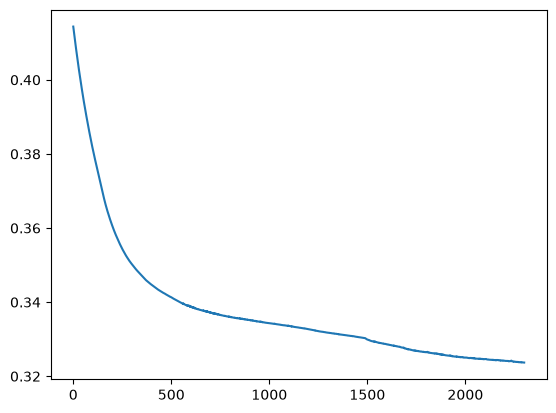

In [45]:
import matplotlib.pyplot as plt
plt.plot(losses[200:])

In [46]:
import pandas as pd
original = X_scaled[0]

reconstructed = model.decode(
    model.encode(
        torch.tensor(X_scaled[0:1], dtype=torch.float32)
    )
).detach().numpy()[0]

comparison = pd.DataFrame({
    "Original": original,
    "Reconstructed": reconstructed
}, index=X.columns)

comparison

,Original,Reconstructed
alcohol,1.518613,1.455087
malic_acid,-0.562250,-0.435753
ash,0.232053,0.243082
alcalinity_of_ash,-1.169593,-1.290863
magnesium,1.913905,0.573783
total_phenols,0.808997,0.984920
flavanoids,1.034819,1.081472
nonflavanoid_phenols,-0.659563,-0.744044
proanthocyanins,1.224884,0.741679
color_intensity,0.251717,0.498295


In [47]:
# rescale to original scale
original = X.iloc[0]
reconstructed = scaler.inverse_transform(reconstructed.reshape(1, -1)).flatten()

comparison = pd.DataFrame({
    "Original": original,
    "Reconstructed": reconstructed
}, index=X.columns)

comparison


,Original,Reconstructed
alcohol,14.23,14.178574
malic_acid,1.71,1.850918
ash,2.43,2.433017
alcalinity_of_ash,15.60,15.196150
magnesium,127.00,107.913567
total_phenols,2.80,2.909791
flavanoids,3.06,3.106469
nonflavanoid_phenols,0.28,0.269516
proanthocyanins,2.29,2.014212
color_intensity,5.64,6.210030


a 2-dimensional representation from which the 13-dimensional input can be reconstructed.

The class separation is an emergent property of that representation.

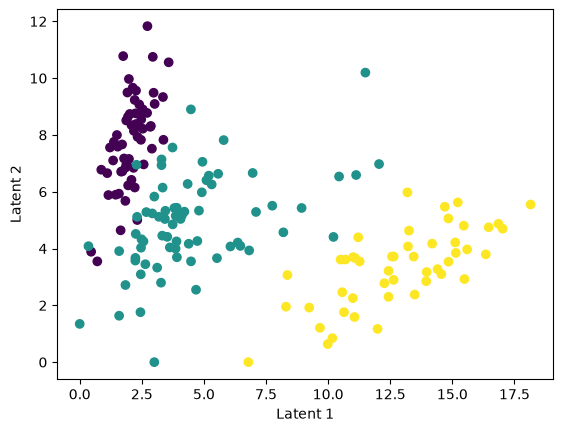

In [48]:
with torch.no_grad():
    Z = model.encode(X_tensor).numpy()

plt.scatter(Z[:, 0], Z[:, 1], c=wine.target)
plt.xlabel("Latent 1")
plt.ylabel("Latent 2")
plt.show()

In [49]:
model.eval()
model.encode(X_tensor[5:6])

tensor([[1.9204, 9.4939]], grad_fn=<ReluBackward0>)

In [50]:
model.decode(torch.tensor([[4.8938, 9.8362]]))

tensor([[-0.2371, -1.0250, -3.0273, -2.0511, -0.5894,  0.8832,  0.6714, -1.4701,
          0.8955, -0.2144,  0.6151,  0.5157, -0.1884]],
       grad_fn=<AddmmBackward0>)

In [51]:
X_tensor[5:6]

tensor([[ 1.4816, -0.5174,  0.3052, -1.2897,  0.8607,  1.5621,  1.3661, -0.1761,
          0.6642,  0.7319,  0.4061,  0.3366,  2.2390]])

Text(0.5, 1.0, 'PCA of Wine Dataset')

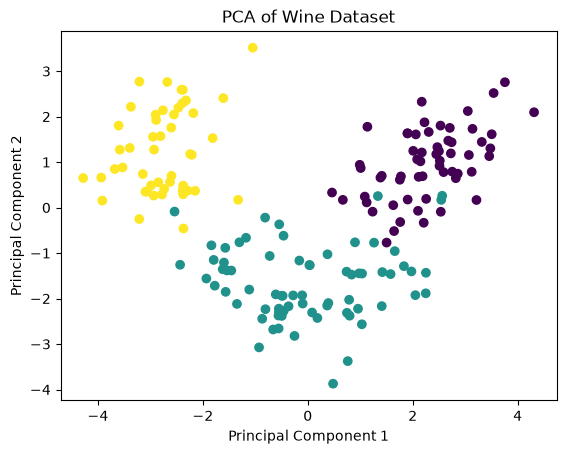

In [52]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=wine.target)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Wine Dataset')
# plt.colorbar()
